<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/disease%20prediction_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip -q install xgboost shap wordcloud

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use("ggplot")

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Light466/My_Programs/main/symptoms_dataset.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(10700, 2)


,Symptoms,Disease
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS)
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV)
2,nausea fatigue sometimes diarrhea or jaundice,Malaria
3,contractions Heavy vaginal bleeding,Late Miscarriage
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy


In [4]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10700 entries, 0 to 10699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Symptoms  10700 non-null  object
 1   Disease   10700 non-null  object
dtypes: object(2)
memory usage: 167.3+ KB


In [5]:
print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

Missing Values
Symptoms    0
Disease     0
dtype: int64


In [6]:
df.dropna(inplace=True)

print("Dataset Shape :",df.shape)

Dataset Shape : (10700, 2)


In [7]:
print("Duplicate Records :",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Dataset Shape :",df.shape)

Duplicate Records : 309
Dataset Shape : (10391, 2)


In [8]:
print(df.describe(include="all"))

                 Symptoms   Disease
count               10391     10391
unique              10355       207
top     dizziness fatigue  Insomnia
freq                    3       100


In [9]:
print("Total Diseases :",df["Disease"].nunique())

Total Diseases : 207


In [10]:
disease_count=df["Disease"].value_counts()

print(disease_count)

Disease
Insomnia                                           100
Pneumonia                                          100
Iron Deficiency Anemia                              99
Delirium                                            99
Skin and Scalp Psoriasis                            99
                                                  ... 
Muscular Back Strain                                43
Mouth Ulcer                                         36
Recurrent Miscarriage                               36
Prenatal Aneuploidy Screening (First Trimester)     12
High Cholesterol                                    11
Name: count, Length: 207, dtype: int64


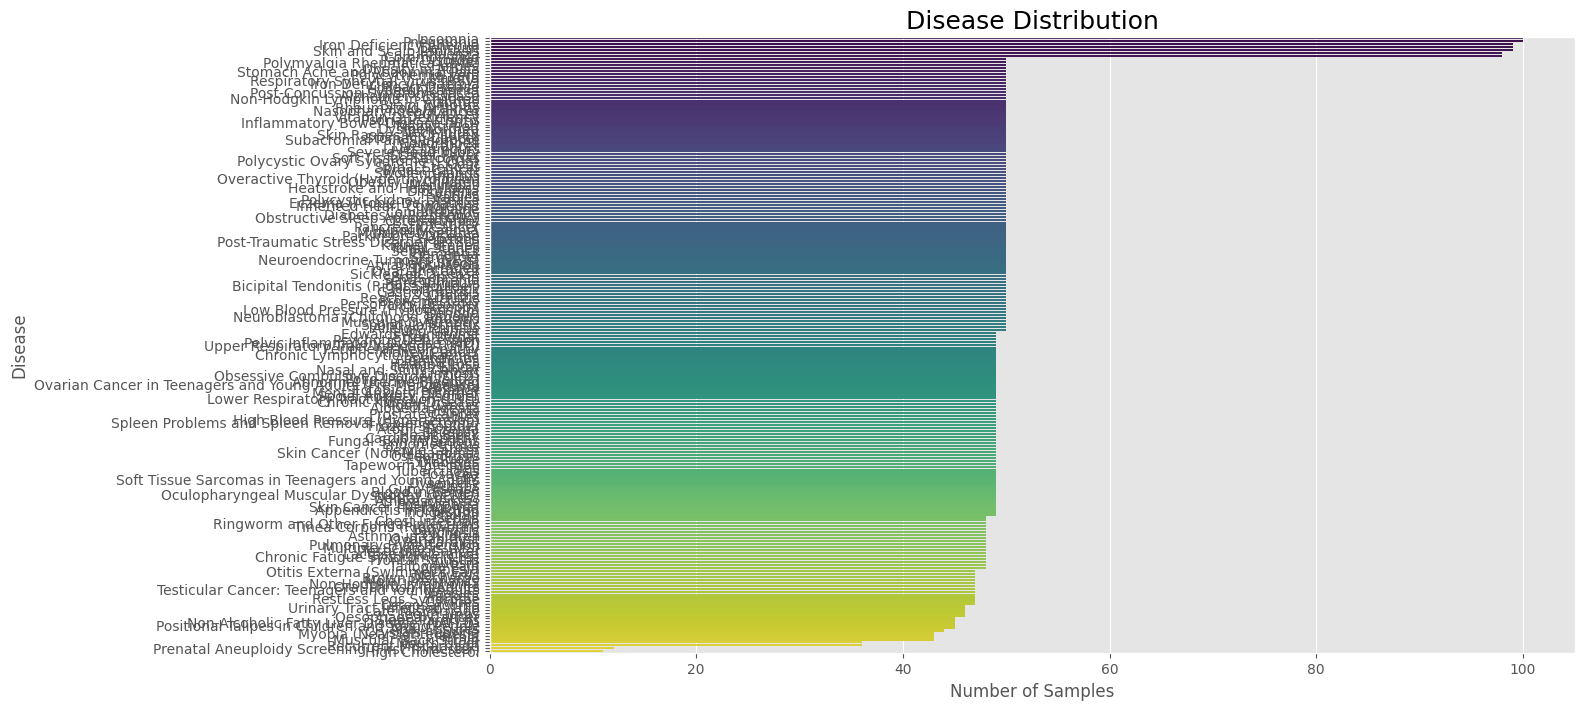

In [11]:
plt.figure(figsize=(14,8))

sns.countplot(
    y=df["Disease"],
    order=df["Disease"].value_counts().index,
    palette="viridis"
)

plt.title("Disease Distribution",fontsize=18)

plt.xlabel("Number of Samples")

plt.ylabel("Disease")

plt.show()

In [12]:
df["Symptom_Length"]=df["Symptoms"].apply(len)

df.head()

,Symptoms,Disease,Symptom_Length
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45
3,contractions Heavy vaginal bleeding,Late Miscarriage,35
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95


In [13]:
print(df["Symptom_Length"].describe())

count    10391.000000
mean        99.337311
std         46.966009
min          8.000000
25%         62.000000
50%         97.000000
75%        133.000000
max        268.000000
Name: Symptom_Length, dtype: float64


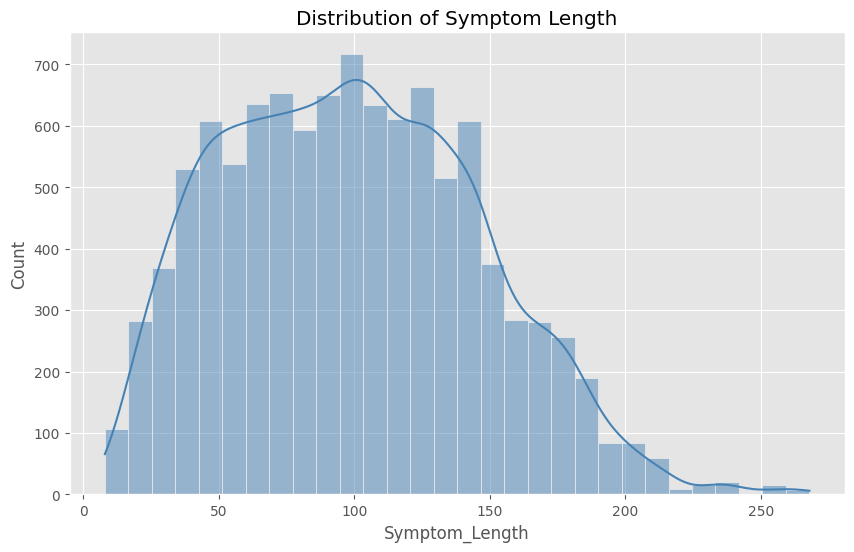

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Symptom_Length"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Symptom Length")

plt.show()

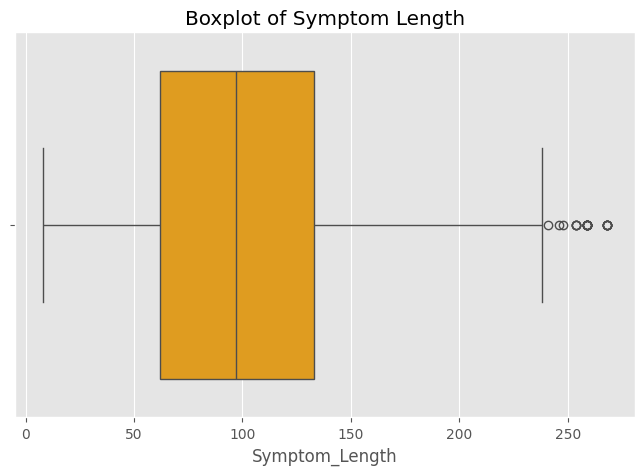

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Symptom_Length"],
    color="orange"
)

plt.title("Boxplot of Symptom Length")

plt.show()

In [16]:
top20=df["Disease"].value_counts().head(20)

print(top20)

Disease
Insomnia                             100
Pneumonia                            100
Iron Deficiency Anemia                99
Delirium                              99
Skin and Scalp Psoriasis              99
Influenza                             98
Common cold                           98
Panic Disorder                        50
Polymyalgia Rheumatica (PMR)          50
Herpes                                50
Obesity in Adults                     50
Stomach Ache and Abdominal Pain       50
Polycythemia Vera                     50
Malaria                               50
Respiratory Syncytial Virus (RSV)     50
Iron Deficiency Anaemia               50
Heart Disease                         50
Hyperglycaemia                        50
Post-Concussion Syndrome (PCS)        50
Alzheimer’s Disease                   50
Name: count, dtype: int64


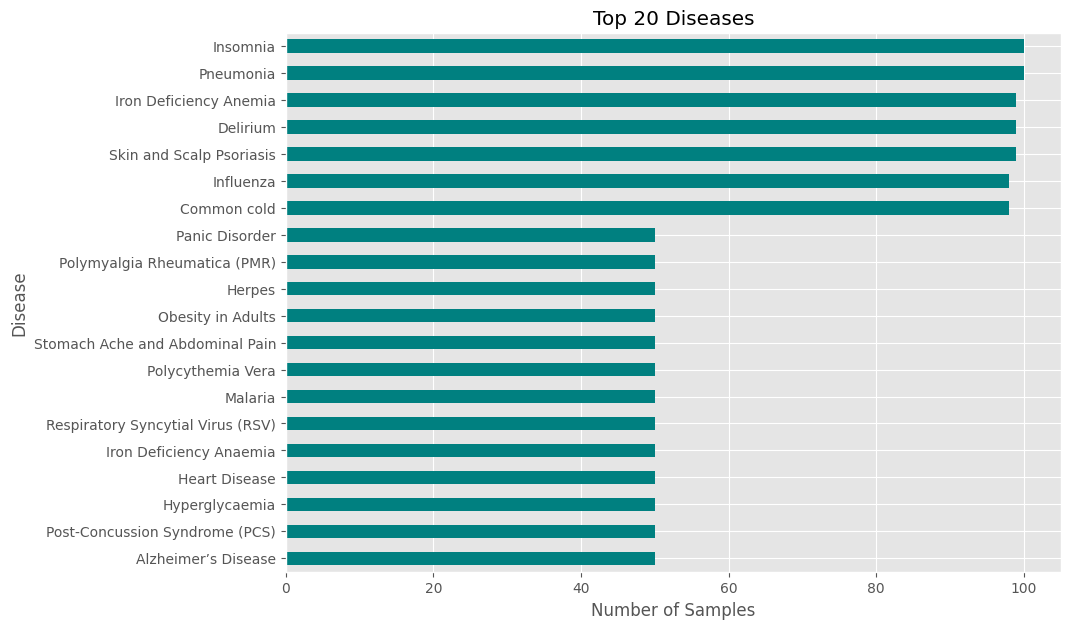

In [17]:
plt.figure(figsize=(10,7))

top20.plot(
    kind="barh",
    color="teal"
)

plt.xlabel("Number of Samples")

plt.title("Top 20 Diseases")

plt.gca().invert_yaxis()

plt.show()

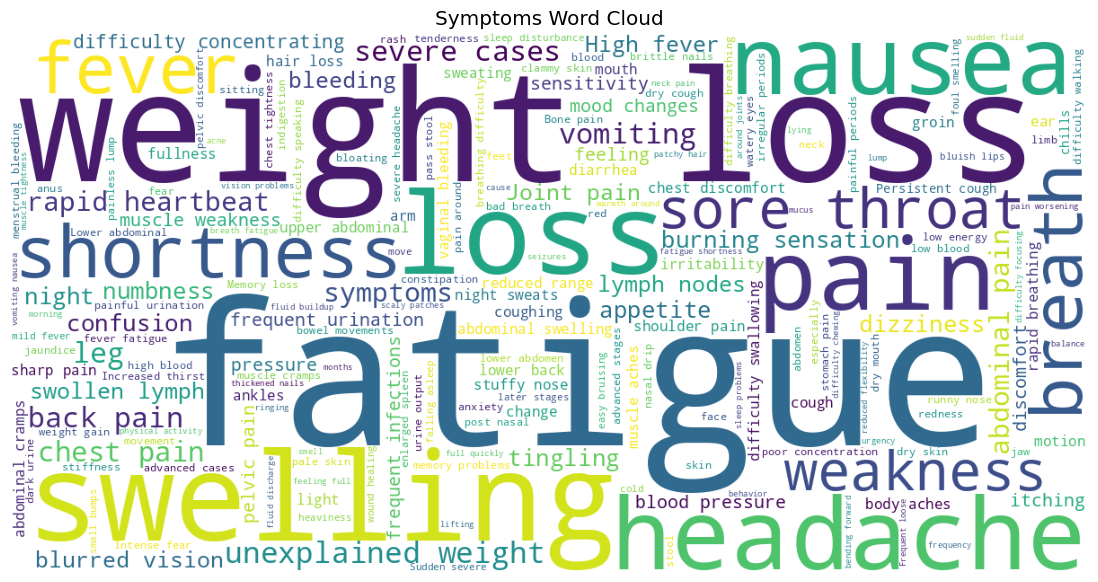

In [18]:
text=" ".join(df["Symptoms"])

wordcloud=WordCloud(

    width=1200,

    height=600,

    background_color="white",

    colormap="viridis"

).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Symptoms Word Cloud")

plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer=CountVectorizer(stop_words="english")

X=vectorizer.fit_transform(df["Symptoms"])

word_counts=np.asarray(X.sum(axis=0)).ravel()

words=vectorizer.get_feature_names_out()

freq=pd.DataFrame({

    "Word":words,

    "Frequency":word_counts

})

freq=freq.sort_values(

    by="Frequency",

    ascending=False

)

freq.head(20)

,Word,Frequency
587,pain,4295
298,fatigue,2575
494,loss,2051
221,difficulty,1817
306,fever,1592
825,swelling,1302
752,skin,1299
544,nausea,1164
7,abdominal,1107
943,weight,1044


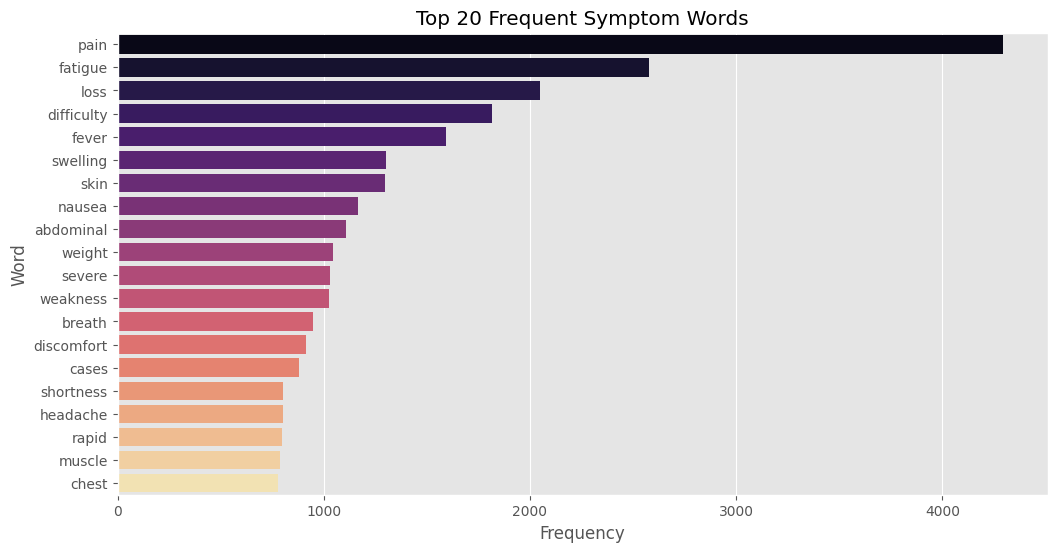

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=freq.head(20),

    x="Frequency",

    y="Word",

    palette="magma"

)

plt.title("Top 20 Frequent Symptom Words")

plt.show()

In [21]:
class_counts=df["Disease"].value_counts()

print(class_counts.describe())

count    207.000000
mean      50.198068
std       10.036071
min       11.000000
25%       49.000000
50%       49.000000
75%       50.000000
max      100.000000
Name: count, dtype: float64


In [22]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [24]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [25]:
df["Clean_Symptoms"] = df["Symptoms"].apply(clean_text)

df.head()

,Symptoms,Disease,Symptom_Length,Clean_Symptoms
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129,fatigue numbness tingling bladder problem cogn...
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159,runny nose wheezing decreased appetite irritab...
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45,nausea fatigue sometimes diarrhea jaundice
3,contractions Heavy vaginal bleeding,Late Miscarriage,35,contraction heavy vaginal bleeding
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95,dizziness symptom early pregnancy missed perio...


In [26]:
for i in range(5):

    print("="*60)

    print("Original :")

    print(df["Symptoms"].iloc[i])

    print()

    print("Cleaned :")

    print(df["Clean_Symptoms"].iloc[i])

Original :
fatigue Numbness or tingling bladder problems cognitive difficulties dizziness difficulty walking muscle weakness vision problems

Cleaned :
fatigue numbness tingling bladder problem cognitive difficulty dizziness difficulty walking muscle weakness vision problem
Original :
Runny nose wheezing decreased appetite irritability in infants rapid or difficult breathing sneezing fever cough sometimes bluish lips or nails in severe cases

Cleaned :
runny nose wheezing decreased appetite irritability infant rapid difficult breathing sneezing fever cough sometimes bluish lip nail severe case
Original :
nausea fatigue sometimes diarrhea or jaundice

Cleaned :
nausea fatigue sometimes diarrhea jaundice
Original :
contractions Heavy vaginal bleeding

Cleaned :
contraction heavy vaginal bleeding
Original :
dizziness symptoms of early pregnancy such as missed period or nausea vaginal bleeding fainting

Cleaned :
dizziness symptom early pregnancy missed period nausea vaginal bleeding faint

In [27]:
X = df["Clean_Symptoms"]

y = df["Disease"]

In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Number of Disease Classes :", len(label_encoder.classes_))

Number of Disease Classes : 207


In [29]:
disease_mapping = pd.DataFrame({

    "Encoded Label": range(len(label_encoder.classes_)),

    "Disease": label_encoder.classes_

})

print(disease_mapping.head(20))

    Encoded Label                                Disease
0               0              Abnormal Uterine Bleeding
1               1                      Allergic Rhinitis
2               2                        Alopecia Areata
3               3                    Alzheimer’s Disease
4               4                                Amnesia
5               5                          Anal Fissures
6               6                           Appendicitis
7               7               Appendicitis in Children
8               8                              Arthritis
9               9                                 Asthma
10             10                     Asthma in Children
11             11                        Atherosclerosis
12             12                          Atopic Eczema
13             13                    Atrial Fibrillation
14             14                                 Autism
15             15  Bicipital Tendonitis (Right Shoulder)
16             16              

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    ngram_range=(1,2),

    min_df=2,

    max_df=0.90,

    max_features=5000,

    sublinear_tf=True
)

In [33]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [34]:
print("Training Shape :", X_train_tfidf.shape)

print("Testing Shape :", X_test_tfidf.shape)

Training Shape : (8312, 5000)
Testing Shape : (2079, 5000)


In [35]:
feature_names = tfidf.get_feature_names_out()

print("Total Features :", len(feature_names))

print(feature_names[:100])

Total Features : 5000
['abdomen' 'abdomen abdominal' 'abdomen advanced' 'abdomen anaemia'
 'abdomen blood' 'abdomen diarrhea' 'abdomen easy' 'abdomen enlarged'
 'abdomen fatigue' 'abdomen fever' 'abdomen frequent' 'abdomen groin'
 'abdomen headache' 'abdomen kidney' 'abdomen loss' 'abdomen nausea'
 'abdomen pain' 'abdomen painless' 'abdomen progressive'
 'abdomen shortness' 'abdomen sudden' 'abdomen vomiting' 'abdominal'
 'abdominal cramp' 'abdominal cramping' 'abdominal discomfort'
 'abdominal flank' 'abdominal fullness' 'abdominal mass' 'abdominal pain'
 'abdominal pelvic' 'abdominal swelling' 'ability' 'ability exercise'
 'abnormal' 'abnormal vaginal' 'abnormality' 'abnormality syndrome'
 'absence' 'absence cough' 'absent' 'absent period' 'ache' 'ache chill'
 'ache cough' 'ache fatigue' 'ache fever' 'ache groin' 'ache headache'
 'ache high' 'ache initial' 'ache loss' 'ache lower' 'ache nausea'
 'ache postnasal' 'ache runny' 'ache sore' 'ache stomach' 'ache swollen'
 'ache vomiting' 

In [36]:
import numpy as np

tfidf_scores = np.asarray(X_train_tfidf.sum(axis=0)).ravel()

feature_df = pd.DataFrame({

    "Feature": feature_names,

    "Score": tfidf_scores

})

feature_df = feature_df.sort_values(

    by="Score",

    ascending=False
)

print(feature_df.head(20))

               Feature       Score
3079              pain  267.231968
1399           fatigue  218.831162
2496              loss  177.261462
1527             fever  159.126089
1016        difficulty  155.673688
2861            nausea  135.883074
1857          headache  131.454005
4316          swelling  130.347515
3924              skin  118.254958
22           abdominal  117.765698
4901          weakness  111.793367
410             breath  110.072917
4946            weight  109.627552
3826            severe  101.962391
2814            muscle  101.714906
3875  shortness breath  100.287586
3874         shortness  100.287586
1079        discomfort   99.713590
4826          vomiting   99.443580
620              chest   99.017691


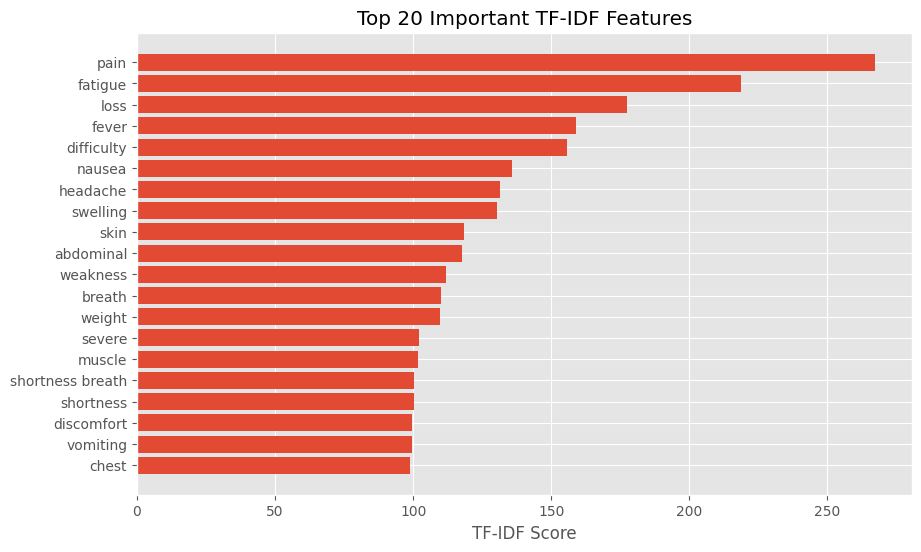

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    feature_df["Feature"][:20],

    feature_df["Score"][:20]

)

plt.gca().invert_yaxis()

plt.xlabel("TF-IDF Score")

plt.title("Top 20 Important TF-IDF Features")

plt.show()

In [38]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully")

TF-IDF Vectorizer Saved Successfully


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [41]:
print("="*70)
print("Training Logistic Regression")
print("="*70)

lr_model = LogisticRegression(

    C=2.0,

    max_iter=500,

    class_weight="balanced",

    solver="lbfgs",

    random_state=42,

    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Training Completed")

Training Logistic Regression
Training Completed


In [42]:
print("Accuracy :",accuracy_score(y_test,lr_pred))

print("Precision :",precision_score(
    y_test,
    lr_pred,
    average="weighted"
))

print("Recall :",recall_score(
    y_test,
    lr_pred,
    average="weighted"
))

print("F1 Score :",f1_score(
    y_test,
    lr_pred,
    average="weighted"
))

Accuracy : 0.9677729677729677
Precision : 0.9704041905454528
Recall : 0.9677729677729677
F1 Score : 0.9674558041596666


In [43]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=label_encoder.classes_
))

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       1.00      0.90      0.95        10
                                             Alopecia Areata       1.00      1.00      1.00        10
                                         Alzheimer’s Disease       1.00      1.00      1.00        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       1.00      1.00      1.00         9
                                                Appendicitis       1.00      0.90      0.95        10
                                    Appendicitis in Children       1.00      0.90      0.95        10
                                                   Arthritis       0.71      0.50

In [44]:
print("="*70)
print("Training Linear SVM")
print("="*70)

svm_model = LinearSVC(

    C=1.0,

    class_weight="balanced",

    random_state=42

)

svm_model.fit(

    X_train_tfidf,

    y_train

)

svm_pred = svm_model.predict(

    X_test_tfidf

)

print("Training Completed")

Training Linear SVM
Training Completed


In [45]:
print("Accuracy :",accuracy_score(y_test,svm_pred))

print("Precision :",precision_score(

    y_test,

    svm_pred,

    average="weighted"

))

print("Recall :",recall_score(

    y_test,

    svm_pred,

    average="weighted"

))

print("F1 Score :",f1_score(

    y_test,

    svm_pred,

    average="weighted"

))

Accuracy : 0.9687349687349688
Precision : 0.9712568038078785
Recall : 0.9687349687349688
F1 Score : 0.9684699908490985


In [46]:
print(classification_report(

    y_test,

    svm_pred,

    target_names=label_encoder.classes_

))

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       1.00      1.00      1.00        10
                                             Alopecia Areata       1.00      1.00      1.00        10
                                         Alzheimer’s Disease       1.00      1.00      1.00        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       1.00      1.00      1.00         9
                                                Appendicitis       1.00      0.90      0.95        10
                                    Appendicitis in Children       1.00      0.90      0.95        10
                                                   Arthritis       0.62      0.50

In [48]:
print("="*70)
print("Training XGBoost")
print("="*70)

xgb_model = XGBClassifier(

    objective="multi:softprob",

    num_class=len(label_encoder.classes_),

    n_estimators=300,

    max_depth=8,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    tree_method="hist",

    eval_metric="mlogloss"

)

xgb_model.fit(

    X_train_tfidf,

    y_train

)

xgb_pred = xgb_model.predict(

    X_test_tfidf

)

print("Training Completed")

Training XGBoost
Training Completed


In [49]:
print("Accuracy :",accuracy_score(

    y_test,

    xgb_pred

))

print("Precision :",precision_score(

    y_test,

    xgb_pred,

    average="weighted"

))

print("Recall :",recall_score(

    y_test,

    xgb_pred,

    average="weighted"

))

print("F1 Score :",f1_score(

    y_test,

    xgb_pred,

    average="weighted"

))

Accuracy : 0.9134199134199135
Precision : 0.9226155537620475
Recall : 0.9134199134199135
F1 Score : 0.9138214797477641


In [50]:
print(classification_report(

    y_test,

    xgb_pred,

    target_names=label_encoder.classes_

))

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       0.90      0.90      0.90        10
                                             Alopecia Areata       0.90      0.90      0.90        10
                                         Alzheimer’s Disease       0.91      1.00      0.95        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       0.80      0.89      0.84         9
                                                Appendicitis       0.82      0.90      0.86        10
                                    Appendicitis in Children       1.00      0.80      0.89        10
                                                   Arthritis       0.78      0.70

In [51]:
results = {

    "Model":[

        "Logistic Regression",

        "Linear SVM",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,svm_pred),

        accuracy_score(y_test,xgb_pred)

    ],

    "Precision":[

        precision_score(y_test,lr_pred,average="weighted"),

        precision_score(y_test,svm_pred,average="weighted"),

        precision_score(y_test,xgb_pred,average="weighted")

    ],

    "Recall":[

        recall_score(y_test,lr_pred,average="weighted"),

        recall_score(y_test,svm_pred,average="weighted"),

        recall_score(y_test,xgb_pred,average="weighted")

    ],

    "F1 Score":[

        f1_score(y_test,lr_pred,average="weighted"),

        f1_score(y_test,svm_pred,average="weighted"),

        f1_score(y_test,xgb_pred,average="weighted")

    ]

}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.967773,0.970404,0.967773,0.967456
1,Linear SVM,0.968735,0.971257,0.968735,0.968470
2,XGBoost,0.913420,0.922616,0.913420,0.913821


In [52]:
import joblib

joblib.dump(lr_model,"logistic_model.pkl")

joblib.dump(svm_model,"svm_model.pkl")

joblib.dump(xgb_model,"xgboost_model.pkl")

print("All Models Saved Successfully")

All Models Saved Successfully


In [53]:
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [54]:
# Logistic Regression
lr = LogisticRegression(

    C=2.0,

    max_iter=500,

    class_weight="balanced",

    random_state=42
)

# Linear SVM with probability calibration
svm = CalibratedClassifierCV(

    estimator=LinearSVC(

        C=1.0,

        class_weight="balanced",

        random_state=42

    ),

    cv=5
)

# XGBoost
xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=len(label_encoder.classes_),

    n_estimators=300,

    learning_rate=0.1,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42
)

In [55]:
estimators = [

    ("lr", lr),

    ("svm", svm),

    ("xgb", xgb)

]

In [56]:
stack_model = StackingClassifier(

    estimators=estimators,

    final_estimator=LogisticRegression(

        max_iter=500,

        random_state=42

    ),

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1,

    passthrough=False
)

In [57]:
print("="*70)
print("Training Hybrid Stacking Model")
print("="*70)

stack_model.fit(

    X_train_tfidf,

    y_train

)

print("Training Completed")

Training Hybrid Stacking Model
Training Completed


In [58]:
stack_pred = stack_model.predict(

    X_test_tfidf
)

In [59]:
accuracy = accuracy_score(

    y_test,

    stack_pred
)

print("Accuracy :",round(accuracy*100,2),"%")

Accuracy : 95.67 %


In [60]:
precision = precision_score(

    y_test,

    stack_pred,

    average="weighted"
)

print("Precision :",round(precision,4))

Precision : 0.9624


In [61]:
recall = recall_score(

    y_test,

    stack_pred,

    average="weighted"
)

print("Recall :",round(recall,4))

Recall : 0.9567


In [62]:
f1 = f1_score(

    y_test,

    stack_pred,

    average="weighted"
)

print("F1 Score :",round(f1,4))

F1 Score : 0.957


In [63]:
print(classification_report(

    y_test,

    stack_pred,

    target_names=label_encoder.classes_
))

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       1.00      0.90      0.95        10
                                             Alopecia Areata       1.00      0.90      0.95        10
                                         Alzheimer’s Disease       1.00      1.00      1.00        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       1.00      1.00      1.00         9
                                                Appendicitis       1.00      0.90      0.95        10
                                    Appendicitis in Children       1.00      0.90      0.95        10
                                                   Arthritis       0.78      0.70

In [64]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Linear SVM",

        "XGBoost",

        "Hybrid Stacking"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,svm_pred),

        accuracy_score(y_test,xgb_pred),

        accuracy_score(y_test,stack_pred)

    ],

    "Precision":[

        precision_score(y_test,lr_pred,average="weighted"),

        precision_score(y_test,svm_pred,average="weighted"),

        precision_score(y_test,xgb_pred,average="weighted"),

        precision_score(y_test,stack_pred,average="weighted")

    ],

    "Recall":[

        recall_score(y_test,lr_pred,average="weighted"),

        recall_score(y_test,svm_pred,average="weighted"),

        recall_score(y_test,xgb_pred,average="weighted"),

        recall_score(y_test,stack_pred,average="weighted")

    ],

    "F1 Score":[

        f1_score(y_test,lr_pred,average="weighted"),

        f1_score(y_test,svm_pred,average="weighted"),

        f1_score(y_test,xgb_pred,average="weighted"),

        f1_score(y_test,stack_pred,average="weighted")

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.967773,0.970404,0.967773,0.967456
1,Linear SVM,0.968735,0.971257,0.968735,0.968470
2,XGBoost,0.913420,0.922616,0.913420,0.913821
3,Hybrid Stacking,0.956710,0.962430,0.956710,0.956995


In [65]:
best = comparison.sort_values(

    by="Accuracy",

    ascending=False
)

print(best)

                 Model  Accuracy  Precision    Recall  F1 Score
1           Linear SVM  0.968735   0.971257  0.968735  0.968470
0  Logistic Regression  0.967773   0.970404  0.967773  0.967456
3      Hybrid Stacking  0.956710   0.962430  0.956710  0.956995
2              XGBoost  0.913420   0.922616  0.913420  0.913821


In [66]:
joblib.dump(

    stack_model,

    "Hybrid_Disease_Prediction_Model.pkl"
)

print("Hybrid Model Saved Successfully")

Hybrid Model Saved Successfully


In [67]:
new_symptom = [

    "fever headache vomiting nausea abdominal pain cough weakness"
]

new_symptom = tfidf.transform(new_symptom)

prediction = stack_model.predict(

    new_symptom
)

predicted_disease = label_encoder.inverse_transform(prediction)

print("Predicted Disease :",predicted_disease[0])

Predicted Disease : Hepatitis


In [1]:
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

import numpy as np

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/Light466/My_Programs/main/symptoms_dataset.csv"

df = pd.read_csv(url)

print(df.head())
print(df.shape)

                                            Symptoms  \
0  fatigue Numbness or tingling bladder problems ...   
1  Runny nose wheezing decreased appetite irritab...   
2      nausea fatigue sometimes diarrhea or jaundice   
3                contractions Heavy vaginal bleeding   
4  dizziness symptoms of early pregnancy such as ...   

                             Disease  
0            Multiple Sclerosis (MS)  
1  Respiratory Syncytial Virus (RSV)  
2                            Malaria  
3                   Late Miscarriage  
4                  Ectopic Pregnancy  
(10700, 2)


In [6]:
df = df.dropna()
df = df.drop_duplicates()

df.columns = ["Symptoms", "Disease"]

In [7]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]
    return " ".join(words)

df["Clean_Symptoms"] = df["Symptoms"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]
    return " ".join(words)

df["Clean_Symptoms"] = df["Symptoms"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["Clean_Symptoms"]
y = df["Disease"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(8312, 5000)


In [10]:
print("="*70)
print("Training Linear SVM")
print("="*70)

svm = SVC(

    kernel="linear",

    probability=True,

    C=2,

    random_state=42

)

svm.fit(

    X_train_tfidf,

    y_train

)

print("Training Completed")

Training Linear SVM
Training Completed


In [11]:
svm_train_prob = svm.predict_proba(X_train_tfidf)

svm_test_prob = svm.predict_proba(X_test_tfidf)

print(svm_train_prob.shape)

print(svm_test_prob.shape)

(8312, 207)
(2079, 207)


In [12]:
num_classes = len(label_encoder.classes_)

model = Sequential()

model.add(Dense(

    128,

    activation="relu",

    input_shape=(num_classes,)

))

model.add(Dropout(0.30))

model.add(Dense(

    64,

    activation="relu"

))

model.add(Dropout(0.20))

model.add(Dense(

    32,

    activation="relu"

))

model.add(Dense(

    num_classes,

    activation="softmax"

))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [15]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True
)

In [16]:
history = model.fit(

    svm_train_prob,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0206 - loss: 5.3033 - val_accuracy: 0.0337 - val_loss: 5.2165
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0492 - loss: 4.9140 - val_accuracy: 0.0986 - val_loss: 4.4205
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2639 - loss: 3.6572 - val_accuracy: 0.7511 - val_loss: 2.5838
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6043 - loss: 2.1686 - val_accuracy: 0.9242 - val_loss: 1.2886
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 1.2710 - val_accuracy: 0.9765 - val_loss: 0.6595
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8637 - loss: 0.8322 - val_accuracy: 0.9880 - val_loss: 0.3854
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9069 - loss: 0.5963 - val_accuracy: 0.9910 - val_loss: 0.2451
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9344 - loss: 0.4510 - val_accu

In [17]:
prediction = model.predict(

    svm_test_prob
)

prediction = np.argmax(

    prediction,

    axis=1
)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [18]:
accuracy = accuracy_score(

    y_test,

    prediction
)

print("Accuracy :",accuracy)

Accuracy : 0.937950937950938


In [19]:
print(

    precision_score(

        y_test,

        prediction,

        average="weighted"

    )
)

0.9584813365571256


In [20]:
print(

    recall_score(

        y_test,

        prediction,

        average="weighted"

    )
)

0.937950937950938


In [21]:
print(

    f1_score(

        y_test,

        prediction,

        average="weighted"

    )
)

0.9436969906889733


In [22]:
print(

    classification_report(

        y_test,

        prediction,

        target_names=label_encoder.classes_

    )
)

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       0.90      0.90      0.90        10
                                             Alopecia Areata       1.00      0.90      0.95        10
                                         Alzheimer’s Disease       1.00      1.00      1.00        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       0.90      1.00      0.95         9
                                                Appendicitis       1.00      0.90      0.95        10
                                    Appendicitis in Children       0.82      0.90      0.86        10
                                                   Arthritis       1.00      0.50

In [23]:
import joblib

joblib.dump(

    svm,

    "SVM_Model.pkl"

)

model.save(

    "Hybrid_SVM_MLP.keras"
)

print("Model Saved")

Model Saved


In [24]:
text = [

    "fever headache cough body pain nausea"

]

text = tfidf.transform(text)

prob = svm.predict_proba(text)

disease = model.predict(prob)

disease = np.argmax(disease)

print(

    label_encoder.inverse_transform([disease])[0]

)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Fungal Skin Infections


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

In [26]:
num_classes = len(label_encoder.classes_)

model = Sequential()

# ---------------- First Hidden Layer ----------------
model.add(Dense(
    512,
    activation="relu",
    input_shape=(svm_train_prob.shape[1],)
))
model.add(BatchNormalization())
model.add(Dropout(0.40))

# ---------------- Second Hidden Layer ----------------
model.add(Dense(
    256,
    activation="relu"
))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# ---------------- Third Hidden Layer ----------------
model.add(Dense(
    128,
    activation="relu"
))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# ---------------- Fourth Hidden Layer ----------------
model.add(Dense(
    64,
    activation="relu"
))
model.add(Dropout(0.20))

# ---------------- Output ----------------
model.add(Dense(
    num_classes,
    activation="softmax"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [29]:
history = model.fit(

    svm_train_prob,

    y_train,

    validation_split=0.20,

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1245 - loss: 4.6916 - val_accuracy: 0.0661 - val_loss: 5.2382 - learning_rate: 5.0000e-04
Epoch 2/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6058 - loss: 2.6533 - val_accuracy: 0.6879 - val_loss: 3.5116 - learning_rate: 5.0000e-04
Epoch 3/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8753 - loss: 1.0978 - val_accuracy: 0.9910 - val_loss: 0.4039 - learning_rate: 5.0000e-04
Epoch 4/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9355 - loss: 0.5277 - val_accuracy: 0.9928 - val_loss: 0.0668 - learning_rate: 5.0000e-04
Epoch 5/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9556 - loss: 0.3198 - val_accuracy: 0.9922 - val_loss: 0.0519 - learning_rate: 5.0000e-04
Epoch 6/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9662 - loss: 0.2347 - val_accuracy: 0.9922 - val_loss: 0.0518 - learning_rate: 5.0000e-04
Epoch 7/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc

In [30]:
prediction = model.predict(svm_test_prob)

prediction = prediction.argmax(axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [31]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    prediction
)

print("Accuracy :",acc)

Accuracy : 0.9543049543049543
